In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Extraction complete.

Using: /content/raw_data/HAR_dataset/HAR_PR_dataset_ver2/examples/Adeel_Walking_1_extracted
Input matrix X: (128, 27)  (timesteps × sensor axes)


 Output shapes: 
  Level 1: (128, 27)
  Level 2: (128, 16)
  Level 3: (128, 16)
  Level 4: (128, 16)




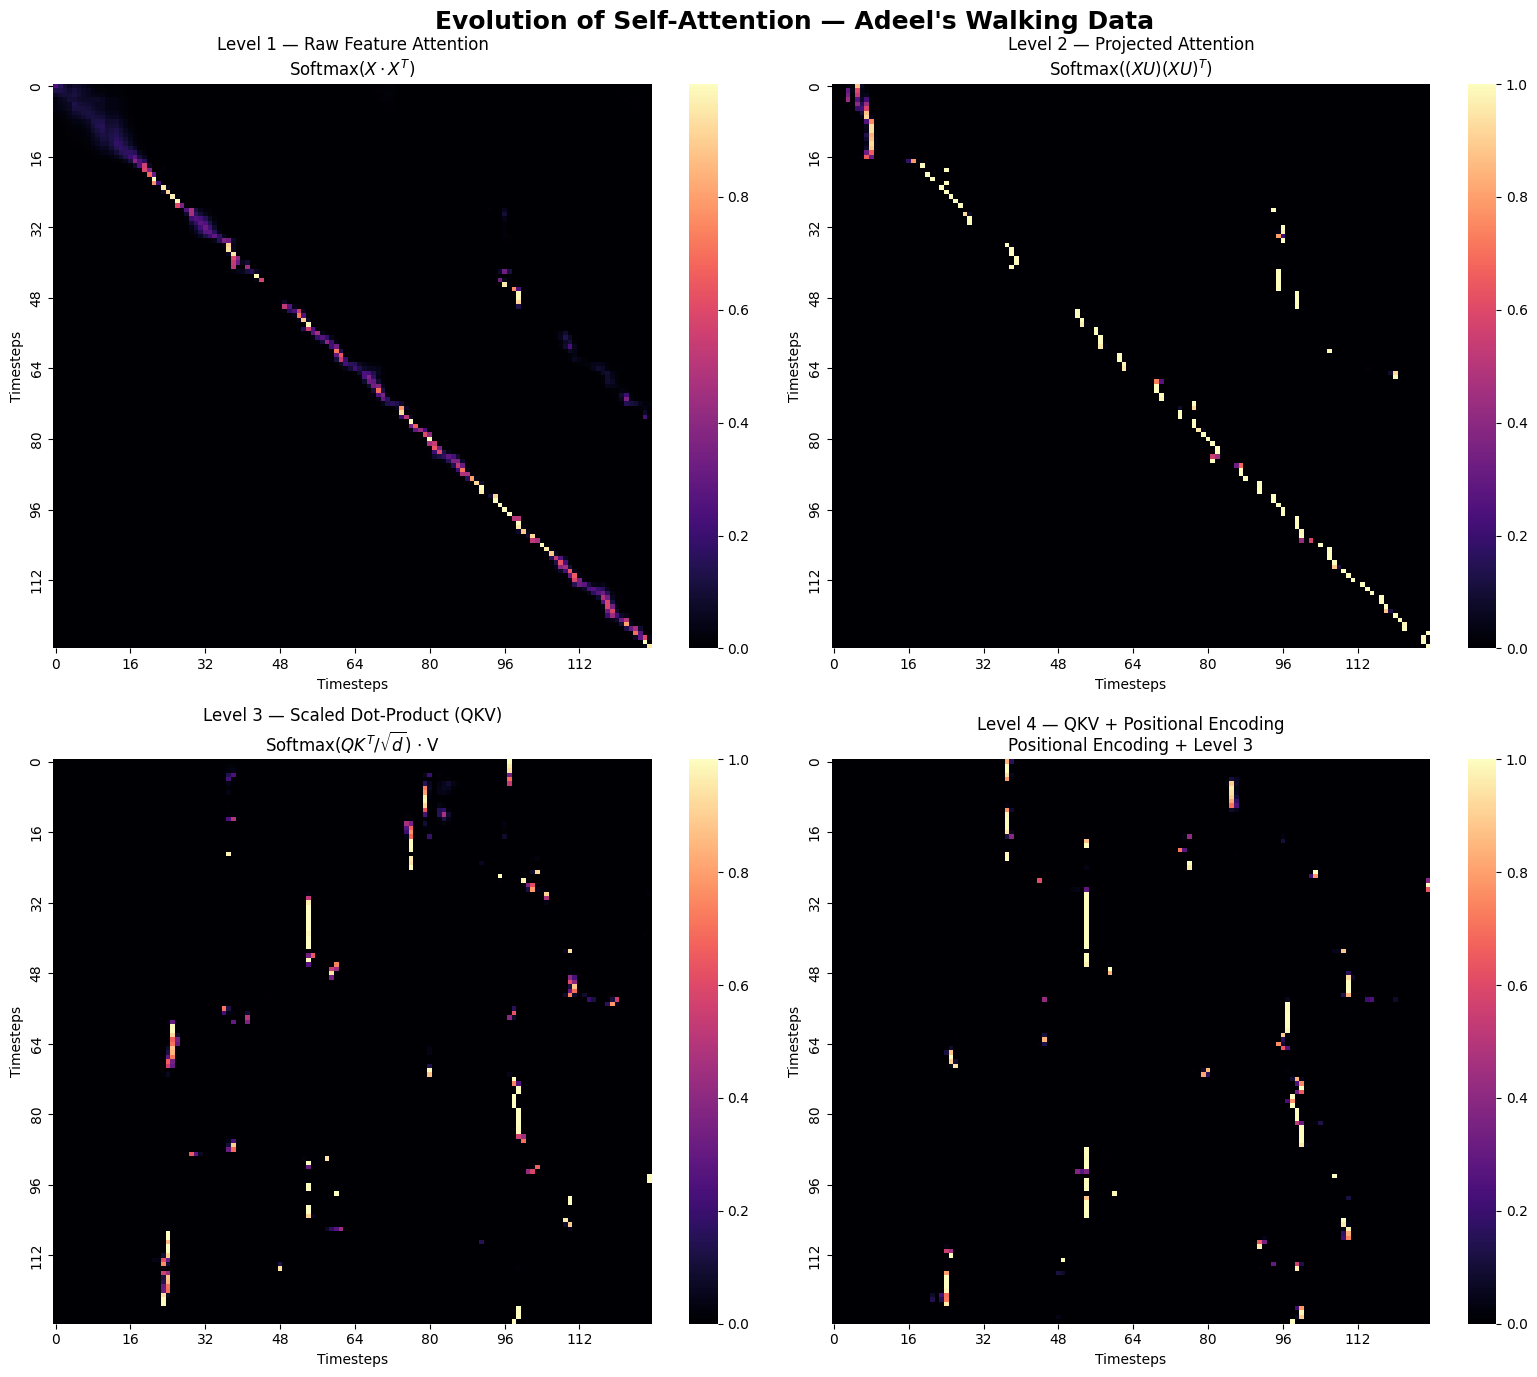

In [5]:
import os
import glob
import zipfile
import tarfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Config
ZIP_PATH    = '/content/drive/MyDrive/sensory_data.zip'
EXTRACT_DIR = '/content/raw_data'
DATASET_DIR = os.path.join(EXTRACT_DIR, 'HAR_dataset')
WINDOW_SIZE = 128
RESAMPLE_MS = '20ms'
PROJ_DIM    = 16
np.random.seed(42)


# Extraction
def extract_dataset():
    os.makedirs(EXTRACT_DIR, exist_ok=True)

    if not any(os.scandir(EXTRACT_DIR)):
        print("Extracting ZIP...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(EXTRACT_DIR)

    if not os.path.exists(DATASET_DIR):
        tar_files = glob.glob(f'{EXTRACT_DIR}/**/*.tar.gz', recursive=True)
        if not tar_files:
            raise FileNotFoundError("No .tar.gz found after ZIP extraction.")
        print(f"Extracting TAR: {tar_files[0]}")
        with tarfile.open(tar_files[0], 'r:gz') as tar:
            filt = 'data' if hasattr(tarfile, 'data_filter') else None
            tar.extractall(path=DATASET_DIR, filter=filt) if filt else tar.extractall(DATASET_DIR)

    print("Extraction complete.\n")


# Data loading
SENSOR_FILES = {
    'Phone_Acc':    'PhoneAccelerometer_Event_{n}.data',
    'Phone_Gyr':    'PhoneGyroscope_Event_{n}.data',
    'Phone_Grav':   'PhoneGravity_Event_{n}.data',
    'Phone_LinAcc': 'PhoneLinearAccelerometer_Event_{n}.data',
    'Phone_Magn':   'PhoneMagnetometer_Event_{n}.data',
    'Watch_Acc':    'android.sensor.accelerometer_Event_{n}.data',
    'Watch_Gyr':    'android.sensor.gyroscope_Event_{n}.data',
    'Glass_Acc':    'JinsAccelerometer_Event_{n}.data',
    'Glass_Gyr':    'JinsGyroscope_Event_{n}.data',
}


def load_event(folder, event_num):
    frames = []
    for sensor, template in SENSOR_FILES.items():
        path = os.path.join(folder, template.format(n=event_num))
        if not os.path.exists(path):
            return None
        try:
            df = pd.read_csv(path, sep=';', header=None, on_bad_lines='skip')
            if df.shape[1] < 2:
                return None
            df = df.rename(columns={0: 'ts'})
            df['ts'] = pd.to_datetime(df['ts'], unit='ms')
            df = df.set_index('ts')
            df.columns = [f'{sensor}_{i}' for i in range(1, len(df.columns) + 1)]
            frames.append(df.resample(RESAMPLE_MS).mean().interpolate('linear'))
        except Exception:
            return None

    if not frames:
        return None
    return pd.concat(frames, axis=1, join='inner').dropna()


def get_subject_data(subject='adeel', activity='walk', event=0):
    examples_dirs = glob.glob(f'{EXTRACT_DIR}/**/examples', recursive=True)
    if not examples_dirs:
        raise FileNotFoundError("Could not find 'examples' directory.")

    target = next(
        (os.path.join(examples_dirs[0], d) for d in os.listdir(examples_dirs[0])
         if subject in d.lower() and activity in d.lower()),
        None
    )
    if not target:
        raise FileNotFoundError(f"No folder found for subject={subject}, activity={activity}.")

    print(f"Using: {target}")
    data = load_event(target, event)
    if data is None or len(data) < WINDOW_SIZE:
        raise ValueError(f"Event {event} has insufficient data (need ≥ {WINDOW_SIZE} timesteps).")

    return data.iloc[:WINDOW_SIZE].values


# Attention math
def softmax(z):
    # Subtract row-max before numerical stability
    e = np.exp(z - z.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)


def normalize(X):
    # Z-score per feature — prevents extreme dot products that collapse softmax
    return (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)


def positional_encoding(seq_len, d_model):
    # Vectorized
    positions = np.arange(seq_len)[:, None]
    dims      = np.arange(0, d_model, 2)[None, :]
    angles    = positions / (10000 ** (dims / d_model))
    pe        = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angles)
    pe[:, 1::2] = np.cos(angles[:, :pe[:, 1::2].shape[1]])
    return pe


def compute_all_levels(X):
    Xn = normalize(X)  # normalized throughout

    # graph 1: raw self-attention
    A1 = softmax(Xn @ Xn.T)
    out1 = A1 @ Xn

    # graph 2: projected attention — reduces dimensionality before scoring
    U  = np.random.randn(Xn.shape[1], PROJ_DIM)
    XU = Xn @ U
    A2 = softmax(XU @ XU.T)
    out2 = A2 @ XU

    # graph 3: scaled dot-product attention with learned Q, K, V projections
    W_Q = np.random.randn(Xn.shape[1], PROJ_DIM)
    W_K = np.random.randn(Xn.shape[1], PROJ_DIM)
    W_V = np.random.randn(Xn.shape[1], PROJ_DIM)
    Q, K, V = Xn @ W_Q, Xn @ W_K, Xn @ W_V
    A3   = softmax(Q @ K.T / np.sqrt(PROJ_DIM))
    out3 = A3 @ V

    # graph 4: same as Level 3 but input carries positional information
    PE   = positional_encoding(Xn.shape[0], Xn.shape[1])
    Xpe  = Xn + PE
    Qpe, Kpe, Vpe = Xpe @ W_Q, Xpe @ W_K, Xpe @ W_V
    A4   = softmax(Qpe @ Kpe.T / np.sqrt(PROJ_DIM))
    out4 = A4 @ Vpe

    return (A1, out1), (A2, out2), (A3, out3), (A4, out4)


# Visualisation
LEVEL_LABELS = [
    ('Level 1 — Raw Feature Attention',      r'Softmax($X \cdot X^T$)'),
    ('Level 2 — Projected Attention',        r'Softmax($(XU)(XU)^T$)'),
    ('Level 3 — Scaled Dot-Product (QKV)',   r'Softmax($QK^T / \sqrt{d}$) $\cdot$ V'),
    ('Level 4 — QKV + Positional Encoding',  r'Positional Encoding + Level 3'),
]


def plot_attention_maps(attention_matrices):
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    fig.suptitle("Evolution of Self-Attention — Adeel's Walking Data", fontsize=18, fontweight='bold', y=0.98)

    for ax, A, (title, subtitle) in zip(axes.flat, attention_matrices, LEVEL_LABELS):
        sns.heatmap(A, cmap='magma', ax=ax, cbar=True, xticklabels=16, yticklabels=16)
        ax.set_title(f'{title}\n{subtitle}', fontsize=12)
        ax.set_xlabel('Timesteps')
        ax.set_ylabel('Timesteps')

    plt.tight_layout()
    plt.savefig('attention_evolution.png', dpi=150, bbox_inches='tight')
    plt.show()

def print_summary(levels):
    print("\n Output shapes: ")
    for i, (_, out) in enumerate(levels, 1):
        print(f"  Level {i}: {out.shape}")
    print("\n")

extract_dataset()

X = get_subject_data(subject='adeel', activity='walk', event=0)
print(f"Input matrix X: {X.shape}  (timesteps × sensor axes)\n")

levels = compute_all_levels(X)
print_summary(levels)

attention_matrices = [A for A, _ in levels]
plot_attention_maps(attention_matrices)